In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')
from common.normalized_env_66k import CoppeliaSimEnv
# from common.normalized_env_66k_legloss import CoppeliaSimEnv
import os
from scipy.signal import hilbert

# ======== Parameters (modify these as needed) ========= #
ENV_ID = "Medauroidea_66k_aug3c"
ALGO = "airl_logit_vx"
FILENAME = "20251007-1539" 
STEP_NUM = "90000-1"  
EPISODE = 2  
start = 140  
end = 170  
fig_length = 4
fig_width = 2

STATES_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_states.csv"
ACTIONS_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_actions.csv"
VEL_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_velocities.csv"
FOOT_TRAJ_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_foot_trajs.csv"

os.makedirs(f"evaluation/{ENV_ID}/{ALGO}/{FILENAME}/step{STEP_NUM}/episode_{EPISODE}/", exist_ok=True)
SAVE_PATH = f"evaluation/{ENV_ID}/{ALGO}/{FILENAME}/step{STEP_NUM}/episode_{EPISODE}"

# ======== Read Data ======== #
states = pd.read_csv(STATES_PATH, header=None, index_col=None)
actions = pd.read_csv(ACTIONS_PATH, header=None, index_col=None)
actions.columns = ['LF_ThC', 'LF_CTr', 'LF_FTi', 'LM_ThC', 'LM_CTr', 'LM_FTi', 'LH_ThC', 'LH_CTr', 'LH_FTi',
                                     'RF_ThC', 'RF_CTr', 'RF_FTi', 'RM_ThC', 'RM_CTr', 'RM_FTi', 'RH_ThC', 'RH_CTr', 'RH_FTi']
                                    #  'RF_ThC', 'RF_CTr', 'RF_FTi', 'RH_ThC', 'RH_CTr', 'RH_FTi']
velocities = pd.read_csv(VEL_PATH, header=None, index_col=None)
foot_trajs = pd.read_csv(FOOT_TRAJ_PATH, header=None, index_col=None)

# ======== Denormalize Data ======== #
env = CoppeliaSimEnv(simulation = False)
states = pd.DataFrame(env.denormalize_observation(states))
actions = env.denormalize_action(actions)

states.columns = [
                #   'body_x', 'body_y',
                  'body_z', 'body_roll', 'body_pitch', 'body_yaw', 
                  'LF_ThC', 'LF_CTr', 'LF_FTi', 'LM_ThC', 'LM_CTr', 'LM_FTi', 'LH_ThC', 'LH_CTr', 'LH_FTi',
                  'RF_ThC', 'RF_CTr', 'RF_FTi', 'RM_ThC', 'RM_CTr', 'RM_FTi', 'RH_ThC', 'RH_CTr', 'RH_FTi',
                  'force_LF', 'force_LM', 'force_LH', 'force_RF', 'force_RM', 'force_RH',
                #   'foot_traj_LF', 'foot_traj_LM', 'foot_traj_LH', 'foot_traj_RF', 'foot_traj_RM', 'foot_traj_RH',
                #   'contact_FL', 'contact_ML', 'contact_HL', 'contact_FR', 'contact_MR', 'contact_HR'
                  ]

lf = states[['LF_ThC', 'LF_CTr', 'LF_FTi']].to_numpy()
lm = states[['LM_ThC', 'LM_CTr', 'LM_FTi']].to_numpy()
lh = states[['LH_ThC', 'LH_CTr', 'LH_FTi']].to_numpy()
rf = states[['RF_ThC', 'RF_CTr', 'RF_FTi']].to_numpy()
rm = states[['RM_ThC', 'RM_CTr', 'RM_FTi']].to_numpy()
rh = states[['RH_ThC', 'RH_CTr', 'RH_FTi']].to_numpy()

# ======== Hilbert phase ======== #
def phase(x):
    h = hilbert(x - np.mean(x))
    return (np.angle(h) + np.pi) / (2 * np.pi)

def inter_limb_plot(leg, start, end):
    phiT, phiC, phiF = map(phase, [leg[:, 0], leg[:, 1], leg[:, 2]])
    # --- Phases ---
    plt.figure(figsize=(fig_length, fig_width))
    plt.plot(np.arange(start, end), phiT[start:end], label="ThC")
    plt.plot(np.arange(start, end), phiC[start:end], label="CTr")
    plt.plot(np.arange(start, end), phiF[start:end], label="FTi")
    plt.title(f"LF Joint Phases", fontsize=18)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    # --- Cyclograms (scatter instead of line) ---
    for (x, y, n1, n2) in [(0, 1, "ThC", "CTr"), (1, 2, "CTr", "FTi"), (0, 2, "ThC", "FTi")]:
        plt.figure(figsize=(3, 3))
        # plt.scatter(lf[a:b, x], lf[a:b, y], s=10, alpha=0.7)
        plt.plot(leg[start:end,x],leg[start:end,y], marker='o', markersize=6, linestyle='-', linewidth=0.5, alpha=0.7)
        plt.xlabel(f"{n1} (rad)", fontsize=16)
        plt.ylabel(f"{n2} (rad)", fontsize=16)
        plt.title(f"Cyclogram {n1}-{n2}", fontsize=18)
        plt.tick_params(axis='both', which='major', labelsize=14)
        plt.tight_layout()
        plt.show()


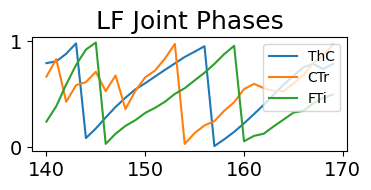

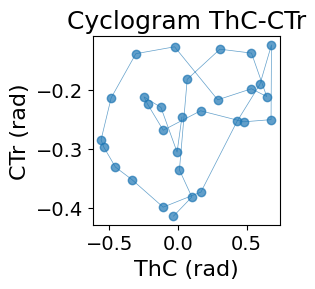

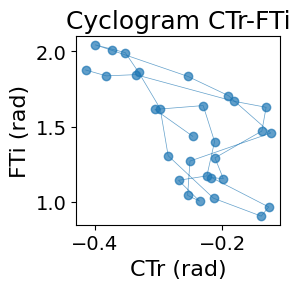

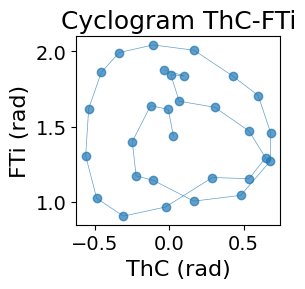

In [38]:
inter_limb_plot(rm, start, end)